# Chapter 5

## Load packages

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
import scipy.stats as stats
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu
from glob import glob
import matplotlib.ticker as mticker
from statannotations.Annotator import Annotator

## Result section 5.4.2 Effect of MAGOH on uORF and mORF expressions

### Load measurements and filter cells according to their area

In [7]:
br1_ctrl = pd.read_csv('/home/chiga034/projects_limgroup/gab/2026/chapter4/measurements/040924_TFN_060924_CYT_measurements_ctrl_2026.tsv', sep ='\t')

# Treatment (tr)
br1_ctrl['tr'] = np.where(br1_ctrl['Image'].str.contains(r'_[AC]_'), 1, 2)

# Condition (protein)
br1_ctrl['treatment'] = 'control'

br1_ctrl.insert(0, 'rep', 1)
br1_ctrl['Image'] = br1_ctrl['Image'].str.extract(r'^([^_]+)')

br1_p1 = pd.read_csv('/home/chiga034/projects_limgroup/gab/2026/chapter4/measurements/040924_TFN_060924_CYT_measurements_p1_2026.tsv', sep ='\t')

# Treatment (tr)
br1_p1['tr'] = np.where(br1_p1['Image'].str.contains(r'_[AC]_'), 1, 2)

# Condition (protein)
br1_p1['treatment'] = np.where(br1_p1['Image'].str.contains(r'_[AB]_'), 'eif4a3', 'magoh')

br1_p1.insert(0, 'rep', 1)
br1_p1['Image'] = br1_p1['Image'].str.extract(r'^([^_]+)')

In [8]:
br2_ctrl = pd.read_csv('/home/chiga034/projects_limgroup/gab/2026/chapter4/measurements/110924_TFN_130924_CYT_measurements_ctrl_2026.tsv', sep ='\t')

# Treatment (tr)
br2_ctrl['tr'] = np.where(br2_ctrl['Image'].str.contains(r'_[AC]_'), 1, 2)

# Condition (protein)
br2_ctrl['treatment'] = 'control'

br2_ctrl.insert(0, 'rep', 2)
br2_ctrl['Image'] = br2_ctrl['Image'].str.extract(r'^([^_]+)')

br2_p1 = pd.read_csv('/home/chiga034/projects_limgroup/gab/2026/chapter4/measurements/110924_TFN_130924_CYT_measurements_p1_2026.tsv', sep ='\t')

#Treatment (tr)
br2_p1['tr'] = np.where(br2_p1['Image'].str.contains(r'_[AC]_'), 1, 2)

# Condition (protein)
br2_p1['treatment'] = np.where(br2_p1['Image'].str.contains(r'_[AB]_'), 'eif4a3', 'magoh')

br2_p1.insert(0, 'rep', 2)
br2_p1['Image'] = br2_p1['Image'].str.extract(r'^([^_]+)')

In [9]:
br3_ctrl = pd.read_csv('/home/chiga034/projects_limgroup/gab/2026/chapter4/measurements/180924_TFN_200924_CYT_measurement_ctrl_2026.tsv', sep ='\t')

# Treatment (tr)
br3_ctrl['tr'] = np.where(br3_ctrl['Image'].str.contains(r'_[AC]_'), 1, 2)

# Condition (protein)
br3_ctrl['treatment'] = 'control'

br3_ctrl.insert(0, 'rep', 3)
br3_ctrl['Image'] = br3_ctrl['Image'].str.extract(r'^([^_]+)')

br3_p1 = pd.read_csv('/home/chiga034/projects_limgroup/gab/2026/chapter4/measurements/180924_TFN_200924_CYT_measurements_p1_2026.tsv', sep ='\t')

#Treatment (tr)
br3_p1['tr'] = np.where(br3_p1['Image'].str.contains(r'_[AC]_'), 1, 2)

# Condition (protein)
br3_p1['treatment'] = np.where(br3_p1['Image'].str.contains(r'_[AB]_'), 'eif4a3', 'magoh')

br3_p1.insert(0, 'rep', 3)
br3_p1['Image'] = br3_p1['Image'].str.extract(r'^([^_]+)')

In [11]:
# Exporting measurements for supplementary file
supp_br1 = br1_p1[br1_p1.treatment=='magoh']
supp_br1 = supp_br1[['Image', 'Classification', 'Nucleus: Area', 'Nucleus: RFP mean', 'Nucleus: RFP sum', 'Nucleus: DAPI mean', 'Nucleus: DAPI sum']]
supp_br1.to_csv('measurements/cytation_rep1_magoh_overexpression_measurements.tsv', sep='\t', index=False)

supp_br2 = br2_p1[br2_p1.treatment=='magoh']
supp_br2 = supp_br2[['Image', 'Classification', 'Nucleus: Area', 'Nucleus: RFP mean', 'Nucleus: RFP sum', 'Nucleus: DAPI mean', 'Nucleus: DAPI sum']]
supp_br2.to_csv('measurements/cytation_rep2_magoh_overexpression_measurements.tsv', sep='\t', index=False)

supp_br3 = br3_p1[br3_p1.treatment=='magoh']
supp_br3 = supp_br3[['Image', 'Classification', 'Nucleus: Area', 'Nucleus: RFP mean', 'Nucleus: RFP sum', 'Nucleus: DAPI mean', 'Nucleus: DAPI sum']]
supp_br3.to_csv('measurements/cytation_rep3_magoh_overexpression_measurements.tsv', sep='\t', index=False)

In [92]:
df = pd.concat([br1_ctrl, br2_ctrl, br3_ctrl, br1_p1, br2_p1, br3_p1]).reset_index(drop=True)

df = df.rename(columns={'Image':'samples', 'Nucleus: Area':'area', 'Nucleus: RFP mean': 'rfp_mean','Nucleus: DAPI mean':'dapi_mean'})
df = df[['rep','tr','treatment','samples','area','rfp_mean','dapi_mean']]

# To get normalised values
median_red = df[df['samples']=='Intronless'].groupby('rep')['rfp_mean'].agg('median').reset_index()
median_blue = df[df['samples']=='Intronless'].groupby('rep')['dapi_mean'].agg('median').reset_index()
median_red.columns = ['rep','rfp_med']
median_blue.columns = ['rep','dapi_med']
median = pd.merge(median_red, median_blue)

df = pd.merge(df, median)

df['rfp_norm'] = df['rfp_mean'] / df['rfp_med']
df['dapi_norm'] = df['dapi_mean'] / df['dapi_med']

# Ratio 
df["RatioBR"] = df["dapi_mean"]/df["rfp_mean"]
df["RatioRB"] = df["rfp_mean"]/df["dapi_mean"]

df["RatioBR_norm"] = df["dapi_norm"]/df["rfp_norm"]
df["RatioRB_norm"] = df["rfp_norm"]/df["dapi_norm"]

df = df[df.treatment!='eif4a3'] # only looking at MAGOH

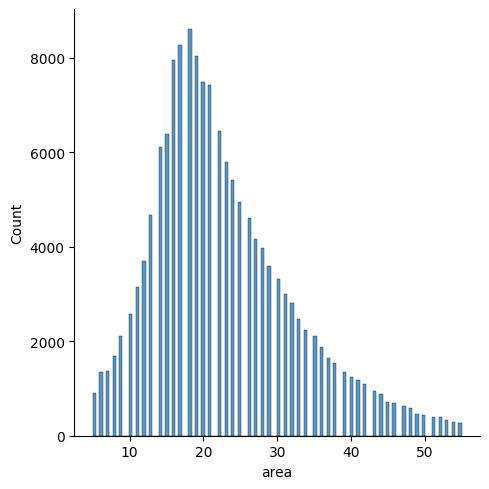

In [8]:
sns.displot(df, x='area')

In [93]:
df = df[(df["area"] > 10) & (df["area"] < 30)]

### Visualisation

In [12]:
#long dataframe 
df_long = pd.melt(df, id_vars=["rep", "tr", "treatment", "samples", "RatioBR"], value_vars=["rfp_mean","dapi_mean"], var_name="reporter", value_name="fi")
df_long['Category'] = df_long['samples'].apply(lambda x: 'Intronless' if x == 'Intronless' else 'Introns')
names = {"uAUG":"P1","uORF":"P2","mAUG":"P3","mORF":"P4","Intronless":"Intronless"}
df_long["samples_pos"]= df_long.samples.apply(lambda x: names[x])

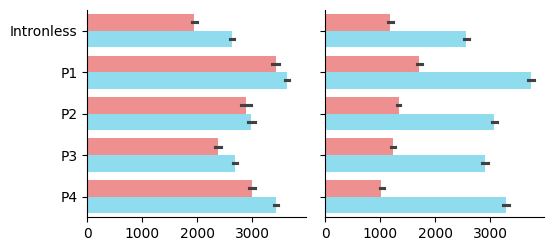

In [88]:
palette = {
    "rfp_mean": "#ff8080",
    "dapi_mean": "#80e5ff"
}

g = sns.catplot(
    data=df_long,
    kind="bar",
    x="fi",
    y="samples_pos",
    hue='reporter',
    col="treatment",
    order=['Intronless','P1','P2','P3','P4'],
    height=3,
    aspect=1, palette=palette
)

g.set_axis_labels("", "")
g.set_titles("")  # clean column titles
g._legend.remove()

# plt.savefig('cyt24/cyt24_oex_plots/fi_across_positions_cyt24_oex_hor.png', dpi=300)
# plt.savefig('cyt24/cyt24_oex_plots/fi_across_positions_cyt24_oex_hor.pdf')

plt.show()

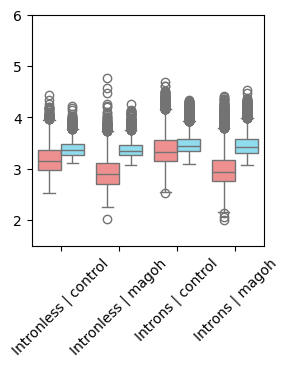

In [89]:
df_long['fi_log'] = np.log10(df_long['fi'])

df_long['Category_treatment'] = df_long['Category'] + " | " + df_long['treatment']

plt.figure(figsize=(3,3))

sns.boxplot(
    data=df_long,
    x='Category_treatment',
    y='fi_log',
    hue='reporter',
    palette=palette, legend=False, 
    order=['Intronless | control','Intronless | magoh', 'Introns | control','Introns | magoh']
)

plt.xticks(rotation=45)
plt.xlabel("")
plt.ylabel("")
plt.ylim(1.5,6.0)

# plt.savefig('cyt24/cyt24_oex_plots/fi_introns_vs_intronless_cyt24_oex.png', dpi=300)
# plt.savefig('cyt24/cyt24_oex_plots/fi_introns_vs_intronless_cyt24_oex.pdf')

plt.show()

In [94]:
#group samples by either having introns or without
df_fil = df[df['samples'].isin(['Intronless','uAUG','mAUG','uORF', 'mORF'])].copy()
df_fil['Category'] = df_fil['samples'].apply(lambda x: 'Intronless' if x == 'Intronless' else 'Introns')

#add intron/sample positions
names = {"uAUG":"P1","uORF":"P2","mAUG":"P3","mORF":"P4","Intronless":"Intronless"}
df_fil["samples_pos"]= df_fil.samples.apply(lambda x: names[x])

df_fil['intron_group'] = df_fil['samples'].apply(lambda x: 'Intronless' if x == 'Intronless' 
                                                            else 'Upstream' if 'u' in x 
                                                            else 'Main' if 'm' in x
                                                            else 'NaN')

/tmp/ipykernel_3922661/985714640.py:10: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(-100, 500)


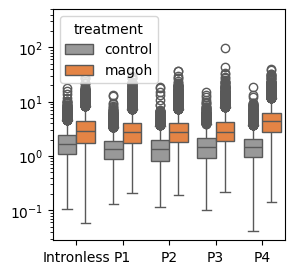

In [96]:
plt.figure(figsize=(3,3))
palette = {
    "control": "#999999",
    "magoh": "#ff7f2a"
}

sns.boxplot(x="samples_pos", y="RatioBR", data=df_fil, palette=palette,
            hue='treatment', order = ['Intronless','P1','P2','P3','P4'])
plt.yscale('log')
plt.ylim(-100, 500)
plt.ylabel("")
plt.xlabel("")

# plt.savefig('cyt24/cyt24_oex_plots/cyt24_comparison_ctrl_p1_oex_ratio_br.png',dpi=300)
# plt.savefig('cyt24/cyt24_oex_plots/cyt24_comparison_ctrl_p1_oex_ratio_br.pdf')

plt.show()

### Statistical tests 

#### Comparison between treatment of the same construct for Figure 5.6(B)

In [24]:
df_med = (df.groupby(['treatment','samples', 'rep'], as_index=False).agg({'rfp_mean': 'median'}))

magoh = df_med[(df_med["treatment"] == "magoh") & (df_med.samples!='Intronless')]["rfp_mean"]
control = df_med[(df_med["treatment"] == "control") & (df_med.samples!='Intronless')]["rfp_mean"]

# t-test (parametric)
t_stat, t_pval = stats.ttest_ind(magoh, control, equal_var=False)
print("sfCherry3C reporter, MAGOH vs Control for Intronless construct: t-test: stat =", t_stat, ", p-value =", t_pval)

sfCherry3C reporter, MAGOH vs Control for Intronless construct: t-test: stat = -6.932890669828306 , p-value = 5.941252821024479e-07


In [25]:
df_med = (df.groupby(['treatment','samples', 'rep'], as_index=False).agg({'dapi_mean': 'median'}))

magoh = df_med[(df_med["treatment"] == "magoh") & (df_med.samples!='Intronless')]["dapi_mean"]
control = df_med[(df_med["treatment"] == "control") & (df_med.samples!='Intronless')]["dapi_mean"]

# t-test (parametric)
t_stat, t_pval = stats.ttest_ind(magoh, control, equal_var=False)
print("mTagBFP2 reporter, MAGOH vs Control for Intronless construct: t-test: stat =", t_stat, ", p-value =", t_pval)

mTagBFP2 reporter, MAGOH vs Control for Intronless construct: t-test: stat = -0.07100288489956545 , p-value = 0.9440390212019096


In [26]:
df_med = (df.groupby(['treatment','samples', 'rep'], as_index=False).agg({'rfp_mean': 'median'}))

magoh = df_med[(df_med["treatment"] == "magoh") & (df_med.samples=='Intronless')]["rfp_mean"]
control = df_med[(df_med["treatment"] == "control") & (df_med.samples=='Intronless')]["rfp_mean"]

# t-test (parametric)
t_stat, t_pval = stats.ttest_ind(magoh, control, equal_var=False)
print("sfCherry3C reporter, MAGOH vs Control for constructs with intron: t-test: stat =", t_stat, ", p-value =", t_pval)

sfCherry3C reporter, MAGOH vs Control for constructs with intron: t-test: stat = -2.2339767352507827 , p-value = 0.0923111032614091


In [27]:
df_med = (df.groupby(['treatment','samples', 'rep'], as_index=False).agg({'dapi_mean': 'median'}))

magoh = df_med[(df_med["treatment"] == "magoh") & (df_med.samples=='Intronless')]["dapi_mean"]
control = df_med[(df_med["treatment"] == "control") & (df_med.samples=='Intronless')]["dapi_mean"]

# t-test (parametric)
t_stat, t_pval = stats.ttest_ind(magoh, control, equal_var=False)
print("mTagBFP2 reporter, MAGOH vs Control for constructs with intron: t-test: stat =", t_stat, ", p-value =", t_pval)

mTagBFP2 reporter, MAGOH vs Control for constructs with intron: t-test: stat = -0.11603238426005885 , p-value = 0.9155897117103792


#### Comparison between treatment of the same construct for Figure 5.6(C)

In [160]:
df_med = (df.groupby(['treatment','samples', 'rep'], as_index=False).agg({'RatioRB': 'median','RatioBR':'median'}))

var = ['Intronless','uAUG','uORF', 'mAUG','mORF']
for i in var:
    g1 = df_med[(df_med.treatment=='control') & (df_med.samples==i)]['RatioBR']
    g2 = df_med[(df_med.treatment=='magoh') & (df_med.samples==i)]['RatioBR']
    
    t_stat, t_pval = stats.ttest_ind(g1, g2) 
    print(f" MAGOH vs Control for {i} RatioBR, t-test: stat = {t_stat}, p-value = {t_pval}")

 MAGOH vs Control for Intronless RatioBR, t-test: stat = -1.431617377512815, p-value = 0.2255112333395424
 MAGOH vs Control for Intronless RatioBR, u-test: stat = 1.0, p-value = 0.2
 MAGOH vs Control for uAUG RatioBR, t-test: stat = -2.954832149165484, p-value = 0.04176826128162456
 MAGOH vs Control for uAUG RatioBR, u-test: stat = 0.0, p-value = 0.1
 MAGOH vs Control for uORF RatioBR, t-test: stat = -3.1922398343871117, p-value = 0.033145267712042036
 MAGOH vs Control for uORF RatioBR, u-test: stat = 0.0, p-value = 0.1
 MAGOH vs Control for mAUG RatioBR, t-test: stat = -2.5149855405333907, p-value = 0.0657070144692475
 MAGOH vs Control for mAUG RatioBR, u-test: stat = 0.0, p-value = 0.1
 MAGOH vs Control for mORF RatioBR, t-test: stat = -3.964807541293593, p-value = 0.01661066780556361
 MAGOH vs Control for mORF RatioBR, u-test: stat = 0.0, p-value = 0.1


## Result section 5.4.4 Presence of introns increases ORF expression
#Refer to Step 1 and 2 in the chapter5_supplementary_figures.ipynb notebook on how to process the raw reading from a .fcs file

### Load preprocessed dataframe & filter

In [3]:
df_dp_gab = pd.read_csv('/home/chiga034/projects_limgroup/gab/2026/chapter4/facs23/facs23_processed_data/facs23_pos_with_with_logicle_gabthreshold.csv')
df_dp_gab = df_dp_gab[['rep','samples','txred_com', 'dapi_com', 'txred_com_logicle', 'dapi_com_logicle', 'RatioBR','RatioRB', 'RatioBR_logicle','RatioRB_logicle']]
df_dp_gab = df_dp_gab[(df_dp_gab.samples!='NC')& (df_dp_gab.samples!='HK10000') & (df_dp_gab.samples!='Mock')]

In [4]:
# To get normalised values
median_red = df_dp_gab[df_dp_gab['samples']=='Intronless'].groupby('rep')['txred_com'].agg('median').reset_index()
median_blue = df_dp_gab[df_dp_gab['samples']=='Intronless'].groupby('rep')['dapi_com'].agg('median').reset_index()
median_red.columns = ['rep','txred_med']
median_blue.columns = ['rep','dapi_med']
median = pd.merge(median_red, median_blue)

# df = p4[p4['Junction position']!='Intronless'].copy()
df_dp_gab = pd.merge(df_dp_gab, median)

df_dp_gab['txred_norm'] = df_dp_gab['txred_com'] / df_dp_gab['txred_med']
df_dp_gab['dapi_norm'] = df_dp_gab['dapi_com'] / df_dp_gab['dapi_med']

In [53]:
#long dataframe 
df_dp_long = pd.melt(df_dp_gab, id_vars=["rep","samples", "RatioBR","RatioRB"], value_vars=["txred_com","dapi_com"], var_name="reporter", value_name="fi")
df_dp_long['Category'] = df_dp_long['samples'].apply(lambda x: 'Intronless' if x == 'Intronless' else 'Introns')
names = {"uAUG":"P1","uORF":"P2","mAUG":"P3","mORF":"P4","Intronless":"Intronless"}
df_dp_long["samples_pos"]= df_dp_long.samples.apply(lambda x: names[x])
df_dp_long['reporter'] = df_dp_long['reporter'].replace({'txred_com':'sfCherry3C','dapi_com':'mTagBFP2'})
df_dp_long['source'] = 'facs'

In [33]:
df_imaging = df_long[df_long.treatment=='control'][['rep', 'samples', 'RatioBR', 'reporter', 'fi', 'Category', 'samples_pos']]
df_imaging['reporter'] = df_imaging['reporter'].replace({'rfp_mean':'sfCherry3C','dapi_mean':'mTagBFP2'})
df_imaging['source'] = 'imaging'

In [54]:
df_comb = pd.concat([df_imaging, df_dp_long]).reset_index(drop=True)
df_comb['fi_log'] = np.log10(df_comb['fi'])

### Visualisation

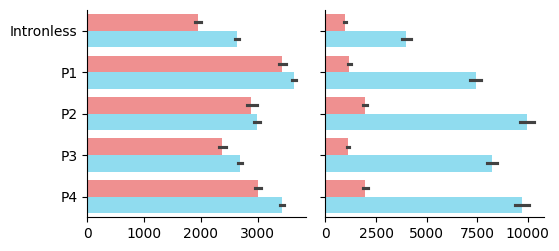

In [83]:
# Figure 5.7(A)
palette = {
    "sfCherry3C": "#ff8080",
    "mTagBFP2": "#80e5ff"
}

g = sns.catplot(
    data=df_comb,
    kind="bar",
    x="fi",
    y="samples_pos",
    hue='reporter',
    col="source",
    order=['Intronless','P1','P2','P3','P4'],
    height=3,
    aspect=1, palette=palette, sharex=False
)

g.set_axis_labels("", "")
g.set_titles("")  # clean column titles
g._legend.remove()
plt.show()

/tmp/ipykernel_3922661/2291486257.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


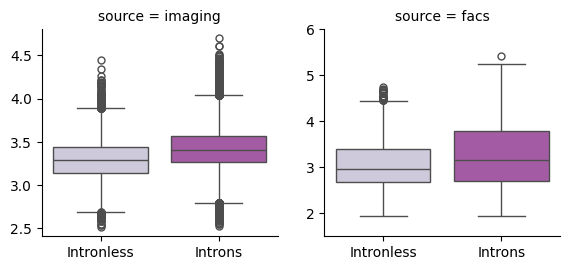

In [86]:
# Figure 5.7(B)
palette = {
    "Intronless": "#cdc7df",
    "Introns": "#af50af"
}

g = sns.catplot(
    data=df_comb,
    x='Category',
    y='fi_log',
    kind='box',
    col='source',
    order=['Intronless', 'Introns'],
    height=3,
    aspect=1, sharey=False, palette=palette
)

plt.ylim(1.5,6)

g.set_axis_labels("", "")
plt.show()

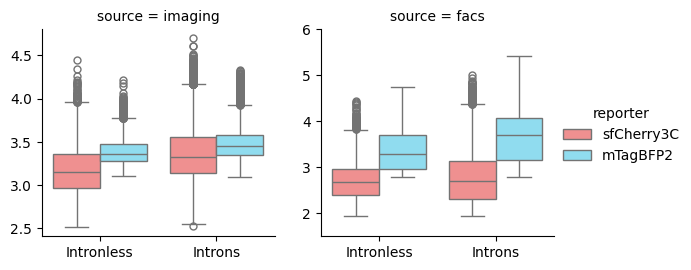

In [97]:
# Figure 5.7 (C)
palette = {
    "sfCherry3C": "#ff8080",
    "mTagBFP2": "#80e5ff"
}

g = sns.catplot(
    data=df_comb,
    x='Category',
    y='fi_log',
    hue='reporter',
    kind='box',
    col='source',
    order=['Intronless', 'Introns'],
    height=3,
    aspect=1, sharey=False, palette=palette
)

plt.ylim(1.5,6)

g.set_axis_labels("", "")
plt.show()

### Statistical tests

In [104]:
df_med = (df_long.groupby(['treatment','samples', 'rep'], as_index=False).agg({'fi': 'median'}))

g1 = df_med[(df_med["treatment"] == "control") & (df_med.samples!='Intronless')]["fi"]
g2 = df_med[(df_med["treatment"] == "control") & (df_med.samples=='Intronless')]["fi"]

# t-test (parametric)
t_stat, t_pval = stats.ttest_ind(g1, g2, equal_var=False)
print("Imaging: Intron vs Intronless overall, t-test: stat =", t_stat, ", p-value =", t_pval)

Imaging: Intron vs Intronless overall, t-test: stat = 2.3008542517629595 , p-value = 0.05852840328582548


In [105]:
df_med = (df_dp_long.groupby(['samples', 'rep'], as_index=False).agg({'fi': 'median'}))

g1 = df_med[df_med.samples!='Intronless']["fi"]
g2 = df_med[df_med.samples=='Intronless']["fi"]

# t-test (parametric)
t_stat, t_pval = stats.ttest_ind(g1, g2, equal_var=False)
print("FACS: Intron vs Intronless overall, t-test: stat =", t_stat, ", p-value =", t_pval)

FACS: Intron vs Intronless overall, t-test: stat = 4.031050785607959 , p-value = 0.001898528536308868


In [106]:
df_med = (df.groupby(['treatment','samples', 'rep'], as_index=False).agg({'rfp_mean': 'median','dapi_mean':'median'}))

var = ['rfp_mean','dapi_mean']
for i in var:
    g1 = df_med[(df_med.treatment=='control') & (df_med.samples!='Intronless')][i]
    g2 = df_med[(df_med.treatment=='control') & (df_med.samples=='Intronless')][i]
    
    t_stat, t_pval = stats.ttest_ind(g1, g2)
    print(f"Imaging: Intron vs Intronless for {i}, t-test: stat = {t_stat}, p-value = {t_pval}")

Imaging: Intron vs Intronless for rfp_mean, t-test: stat = 2.1358336217546565, p-value = 0.05229060302181993
Imaging: Intron vs Intronless for dapi_mean, t-test: stat = 1.3020073180284562, p-value = 0.21551172434575164


In [107]:
df_med = (df_dp_gab.groupby(['samples', 'rep'], as_index=False).agg({'txred_com': 'median','dapi_com':'median'}))

var = ['txred_com','dapi_com']
for i in var:
    g1 = df_med[df_med['samples']!='Introns'][i]
    g2 = df_med[df_med['samples']=='Intronless'][i]

    t_stat, t_pval = stats.ttest_ind(g1, g2) 
    print(f"FACS: Introns vs intronless for {i}, t-test: stat = {t_stat}, p-value = {t_pval}")

FACS: Introns vs intronless for txred_com, t-test: stat = 0.5933567948014772, p-value = 0.5612372816776282
FACS: Introns vs intronless for dapi_com, t-test: stat = 2.2135041214973348, p-value = 0.04173784702745213


## Result section 5.4.5 uATG-distal intron has stronger effect on mORF expression

In [66]:
#group samples by either having introns or without
df_dp_fil = df_dp_gab[df_dp_gab['samples'].isin(['Intronless','uAUG','mAUG','uORF', 'mORF'])].copy()
df_dp_fil['Category'] = df_dp_fil['samples'].apply(lambda x: 'Intronless' if x == 'Intronless' else 'Introns')

#add intron/sample positions
names = {"uAUG":"P1","uORF":"P2","mAUG":"P3","mORF":"P4","Intronless":"Intronless"}

df_dp_fil["samples_pos"]= df_dp_fil.samples.apply(lambda x: names[x])

df_dp_fil['intron_group'] = df_dp_fil['samples'].apply(lambda x: 'Intronless' if x == 'Intronless' 
                                                            else 'Upstream' if 'u' in x 
                                                            else 'Main' if 'm' in x
                                                            else 'NaN')

df_dp_fil_woi = df_dp_fil[(df_dp_fil.samples=='uAUG')|(df_dp_fil.samples=='uORF')|(df_dp_fil.samples=='mAUG')|(df_dp_fil.samples=='mORF')].copy()

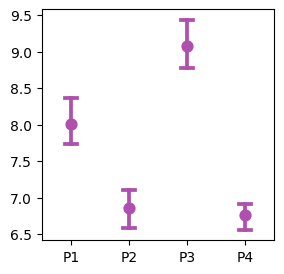

In [82]:
plt.figure(figsize=(3, 3))

g = sns.pointplot(
    data=df_dp_fil_woi,
    x='samples_pos',
    y='RatioBR',
    estimator=np.median,
    errorbar=('ci', 91), order=['P1','P2','P3','P4'],
    markers='o',  linestyles='none', capsize=0.2, color="#af50af"
)

plt.ylabel("")
plt.xlabel("")
plt.show()

In [75]:
df_plot = df_dp_fil.copy()

# Get intronless medians for both ratios
medians = df_plot[df_plot['samples'] == 'Intronless'][['RatioBR', 'RatioRB']].median()

# Compute log2FC per cell for both
df_plot['log2FC_BR'] = np.log2(df_plot['RatioBR'] / medians['RatioBR'])
df_plot['log2FC_RB'] = np.log2(df_plot['RatioRB'] / medians['RatioRB'])

df_med = (df_plot.groupby(['samples', 'rep'], as_index=False).agg({'log2FC_BR': 'median','log2FC_RB':'median'}))

var = ['uAUG','uORF', 'mAUG','mORF']

results_br = []

for i in var:
    g1 = df_med[df_med['samples'] == i]['log2FC_BR']
    g2 = df_med[df_med['samples'] == 'Intronless']['log2FC_BR']
    
    t_stat, t_pval = stats.ttest_ind(g1, g2)
    
    results_br.append({
        'samples': i,
        'reference': 'Intronless',
        't_stat': t_stat,
        'p_value': t_pval
    })

results_rb = []

for i in var:
    g1 = df_med[df_med['samples'] == i]['log2FC_RB']
    g2 = df_med[df_med['samples'] == 'Intronless']['log2FC_RB']
    
    t_stat, t_pval = stats.ttest_ind(g1, g2)
    
    results_rb.append({
        'samples': i,
        'reference': 'Intronless',
        't_stat': t_stat,
        'p_value': t_pval
    })

df_ttest_br = pd.DataFrame(results_br)
df_ttest_rb = pd.DataFrame(results_rb)

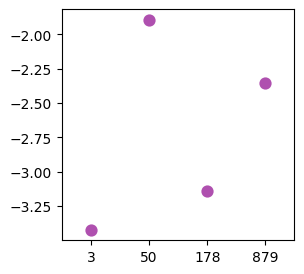

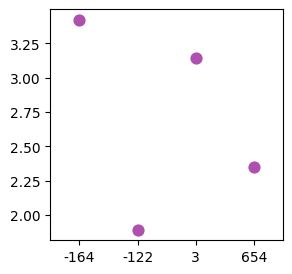

In [81]:
plt.figure(figsize=(3, 3))
pos={'uAUG':3,'uORF':50,'mAUG':178,'mORF':879} # relative to the uAUG
df_ttest_rb["SJ_position"]= df_ttest_rb.samples.apply(lambda x: pos[x]).astype(int)

# --- RatioRB  ---
sns.pointplot(
    data=df_ttest_rb,
    x='SJ_position',
    y='t_stat',
    errorbar=('ci', 91),
    capsize=0.2, linestyles='none', color="#af50af"
)
plt.xlabel('')
plt.ylabel('')
# plt.savefig('facs23/facs23_plots/log2fc_ratiorb_ttest.png', dpi=300)
# plt.savefig('facs23/facs23_plots/log2fc_ratiorb_ttest.pdf')
plt.show()

plt.figure(figsize=(3, 3))
pos={'uAUG':'-164','uORF':'-122','mAUG':'+3','mORF':'+654'} # relative to the mAUG 
df_ttest_br["SJ_position"]= df_ttest_rb.samples.apply(lambda x: pos[x]).astype(int)

samples = ['uAUG','uORF','mAUG', 'mORF']

# --- RatioBR ---
sns.pointplot(
    data=df_ttest_br,
    x='SJ_position',
    y='t_stat',
    errorbar=('ci', 91),   # or 'se'
    capsize=0.2, linestyles='none', color="#af50af"
)
# plt.title('log2FC (RatioBR)')
plt.xlabel('')
plt.ylabel('')
# plt.savefig('facs23/facs23_plots/log2fc_ratiobr_ttest.png', dpi=300)
# plt.savefig('facs23/facs23_plots/log2fc_ratiobr_ttest.pdf')
plt.show()